# 03 — Dataset Evaluation
**Project:** Disease Detection and Fungicide Treatment Recommendation for Rosa damascena

This notebook evaluates the quality of all downloaded image datasets before
training. For each dataset we assess:
- Class distribution and image counts
- Image resolution statistics
- Blur detection via Laplacian variance
- Brightness distribution
- Visual inspection (sample grids)

Datasets that fail quality thresholds are flagged or excluded.


In [20]:
import os
import cv2
import yaml
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
DATASETS_DIR = Path("../datasets/")

print("Libraries loaded")
print(f"Datasets directory: {DATASETS_DIR.resolve()}")
print(f"Datasets found: {[d.name for d in DATASETS_DIR.iterdir() if d.is_dir()]}")

Libraries loaded
Datasets directory: I:\SoftUni\Machine Learning\Machine_Learning_Project\datasets
Datasets found: ['rose_leaf_disease_dataset', 'rose leaf diseases.v4i.yolov11_roboflow', 'rose leaf detection.v1i.yolov11_roboflow', 'rose_leaves_disease_detection', 'Multifaceted Rose Leaf Disease Dataset for AI-Driv']


## Setup

Libraries loaded and datasets directory accessible. Found 5 image datasets:

- 2 in classification format (folder-per-class)
- 2 in YOLO format (images + label files)
- 1 Multifaced dataset with most different class folders

All datasets are read-only in this notebook - no files are modified.

In [3]:
classification_datasets = [
    "rose_leaf_disease_dataset",
    "rose_leaves_disease_detection",
    "Multifaceted Rose Leaf Disease Dataset for AI-Driv"
]

yolo_datasets = [
    "rose leaf diseases.v4i.yolov11_roboflow",
    "rose leaf detection.v1i.yolov11_roboflow"
]

def count_classification_images(dataset_path):
    counts = {}
    for class_dir in sorted(dataset_path.rglob("*")):
        if class_dir.is_dir():
            images = list(class_dir.glob("*.jpg")) + \
                     list(class_dir.glob("*.jpeg")) + \
                     list(class_dir.glob("*.png"))
            if images:
                rel = class_dir.relative_to(dataset_path)
                counts[str(rel)] = len(images)
    return counts

for name in classification_datasets:
    path = DATASETS_DIR / name
    print(f"\n{name}:")
    counts = count_classification_images(path)
    total = 0
    for folder, count in counts.items():
        print(f"  {folder}: {count} images")
        total += count
    print(f"  TOTAL: {total}")


rose_leaf_disease_dataset:
  test\Healthy_Leaf_Rose: 78 images
  test\Rose_Rust: 53 images
  test\Rose_sawfly_Rose_slug: 79 images
  train\Healthy_Leaf_Rose: 2450 images
  train\Rose_Rust: 2450 images
  train\Rose_sawfly_Rose_slug: 2450 images
  validation\Healthy_Leaf_Rose: 2450 images
  validation\Rose_Rust: 2450 images
  validation\Rose_sawfly_Rose_slug: 2450 images
  TOTAL: 14910

rose_leaves_disease_detection:
  Black Spot: 313 images
  Downy Mildew: 200 images
  Fresh Leaf: 404 images
  TOTAL: 917

Multifaceted Rose Leaf Disease Dataset for AI-Driv:
  Rose leaf dataset\Black Spot: 3000 images
  Rose leaf dataset\Downy Mildew: 1102 images
  Rose leaf dataset\Fresh Leaf: 3844 images
  Rose leaf dataset\Insect  Hole: 2360 images
  Rose leaf dataset\POWDERY_MILDEW: 1000 images
  Rose leaf dataset\ROSE_MOSAIC: 1000 images
  Rose leaf dataset\ROSE_RUST: 1000 images
  TOTAL: 13306


## Results — Image Count per Class

### rose_leaf_disease_dataset (14,910 total)
| Split | Class | Count |
|---|---|---|
| train | Healthy_Leaf_Rose | 2,450 |
| train | Rose_Rust | 2,450 |
| train | Rose_sawfly_Rose_slug | 2,450 |
| validation | Healthy_Leaf_Rose | 2,450 |
| validation | Rose_Rust | 2,450 |
| validation | Rose_sawfly_Rose_slug | 2,450 |
| test | Healthy_Leaf_Rose | 78 |
| test | Rose_Rust | 53 |
| test | Rose_sawfly_Rose_slug | 79 |

Train/validation are perfectly balanced (2,450 each). Test set is small and unbalanced (~55-79 images per class). Rose_sawfly_Rose_slug is an insect pest, not a fungal disease — not relevant to our detection goal.

### rose_leaves_disease_detection (917 total)
Small dataset with 3 classes: Black Spot (313), Downy Mildew (200), Fresh Leaf (404). Mildly unbalanced.

### Multifaceted Rose Leaf Disease Dataset (13,306 total)
Most comprehensive: 7 classes including Black Spot (3,000), ROSE_RUST (1,000), POWDERY_MILDEW (1,000),
ROSE_MOSAIC (1,000), Downy Mildew (1,102), Insect Hole (2,360), Fresh Leaf (3,844).
Unbalanced — Fresh Leaf and Black Spot dominate.


In [7]:
import yaml

def inspect_yolo_dataset(dataset_path):
    # Find yaml config
    yaml_files = list(dataset_path.glob("*.yaml"))
    if not yaml_files:
        print("  No .yaml file found!")
        return
    
    with open(yaml_files[0], "r") as f:
        config = yaml.safe_load(f)
    
    class_names = config.get("names", [])
    print(f"  Config file: {yaml_files[0].name}")
    print(f"  Classes ({len(class_names)}): {class_names}")
    
    splits = ["train", "valid", "test"]
    for split in splits:
        images_dir = dataset_path / split / "images"
        labels_dir = dataset_path / split / "labels"
        if not images_dir.exists():
            continue
        
        images = list(images_dir.glob("*.jpg")) + \
                 list(images_dir.glob("*.jpeg")) + \
                 list(images_dir.glob("*.png"))
        
        class_counts = {i: 0 for i in range(len(class_names))}
        multi_class_images = 0
        
        for img_path in images:
            label_path = labels_dir / (img_path.stem + ".txt")
            if label_path.exists():
                with open(label_path, "r") as f:
                    lines = [l.strip() for l in f if l.strip()]
                classes_in_image = set(int(l.split()[0]) for l in lines)
                if len(classes_in_image) > 1:
                    multi_class_images += 1
                for cls_id in classes_in_image:
                    if cls_id in class_counts:
                        class_counts[cls_id] += 1
        
        print(f"\n  [{split}] — {len(images)} images")
        for cls_id, count in class_counts.items():
            print(f"    {class_names[cls_id]}: {count}")
        if multi_class_images:
            print(f"    Multi-class images (unusable for classification): {multi_class_images}")

for name in yolo_datasets:
    path = DATASETS_DIR / name
    print(f"\n{name}:")
    inspect_yolo_dataset(path)


rose leaf diseases.v4i.yolov11_roboflow:
  Config file: data.yaml
  Classes (4): ['Black Spot', 'Downy Mildew', 'Normal', 'Powdery Mildew']

  [train] — 3417 images
    Black Spot: 933
    Downy Mildew: 864
    Normal: 822
    Powdery Mildew: 798

  [valid] — 142 images
    Black Spot: 0
    Downy Mildew: 66
    Normal: 76
    Powdery Mildew: 0

  [test] — 143 images
    Black Spot: 0
    Downy Mildew: 9
    Normal: 0
    Powdery Mildew: 134

rose leaf detection.v1i.yolov11_roboflow:
  Config file: data(1).yaml
  Classes (3): ['Blackspot', 'DownyMildew', 'Healthy']

  [train] — 1900 images
    Blackspot: 633
    DownyMildew: 414
    Healthy: 844

  [valid] — 183 images
    Blackspot: 60
    DownyMildew: 40
    Healthy: 81

  [test] — 91 images
    Blackspot: 31
    DownyMildew: 20
    Healthy: 40


## Results — YOLO Dataset Inspection

### rose leaf diseases.v4i.yolov11_roboflow (3,702 total)
4 classes: `Black Spot`, `Downy Mildew`, `Normal`, `Powdery Mildew`.
Train split (3,417 images) is reasonably balanced across all classes.
**Critical issue:** valid and test splits do not cover all classes —
`Black Spot` is entirely absent from both valid and test;
`Normal (Healthy leaves)` is absent from test.
`Splits` will be discarded during conversion; all images will be merged and re-split.
No multi-class images detected.

### rose leaf detection.v1i.yolov11_roboflow (2,174 total)
3 classes: `Blackspot`, `DownyMildew`, `Healthy leaves`.
All three splits (train/valid/test) cover all classes with balanced distribution.
No multi-class images detected.

In [12]:
SAMPLE_RATE = 0.10
SAMPLE_MIN = 50
SAMPLE_MAX = 500

def laplacian_variance(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def sample_images(image_list):
    n = int(len(image_list) * SAMPLE_RATE)
    n = max(SAMPLE_MIN, min(SAMPLE_MAX, n))
    if len(image_list) <= n:
        return image_list
    indices = np.linspace(0, len(image_list) - 1, n, dtype=int)
    return [image_list[i] for i in indices]

BLUR_THRESHOLD = 100.0
results = {}

# Classification datasets
for name in classification_datasets:
    path = DATASETS_DIR / name
    dataset_scores = []
    for class_dir in sorted(path.rglob("*")):
        if not class_dir.is_dir():
            continue
        images = list(class_dir.glob("*.jpg")) + \
                 list(class_dir.glob("*.jpeg")) + \
                 list(class_dir.glob("*.png"))
        if not images:
            continue
        for img_path in sample_images(images):
            score = laplacian_variance(img_path)
            if score is not None:
                dataset_scores.append(score)
    results[name] = dataset_scores

# YOLO datasets
for name in yolo_datasets:
    path = DATASETS_DIR / name
    dataset_scores = []
    all_images = []
    for split in ["train", "valid", "test"]:
        images_dir = path / split / "images"
        if images_dir.exists():
            all_images += list(images_dir.glob("*.jpg")) + \
                          list(images_dir.glob("*.jpeg")) + \
                          list(images_dir.glob("*.png"))
    for img_path in sample_images(all_images):
        score = laplacian_variance(img_path)
        if score is not None:
            dataset_scores.append(score)
    results[name] = dataset_scores

# Print summary
for name, scores in results.items():
    scores = np.array(scores)
    blurry = np.sum(scores < BLUR_THRESHOLD)
    print(f"\n{name}:")
    print(f"  Sampled: {len(scores)} images")
    print(f"  Mean blur score:   {scores.mean():.1f}")
    print(f"  Median blur score: {np.median(scores):.1f}")
    print(f"  Min: {scores.min():.1f}  Max: {scores.max():.1f}")
    print(f"  Below threshold ({BLUR_THRESHOLD}): {blurry} ({100*blurry/len(scores):.1f}%)")


rose_leaf_disease_dataset:
  Sampled: 1620 images
  Mean blur score:   5884.3
  Median blur score: 228.1
  Min: 49.8  Max: 40629.8
  Below threshold (100.0): 126 (7.8%)

rose_leaves_disease_detection:
  Sampled: 150 images
  Mean blur score:   374.7
  Median blur score: 190.1
  Min: 12.9  Max: 4250.7
  Below threshold (100.0): 41 (27.3%)

Multifaceted Rose Leaf Disease Dataset for AI-Driv:
  Sampled: 1330 images
  Mean blur score:   95.1
  Median blur score: 38.2
  Min: 1.3  Max: 3494.2
  Below threshold (100.0): 1044 (78.5%)

rose leaf diseases.v4i.yolov11_roboflow:
  Sampled: 370 images
  Mean blur score:   428.4
  Median blur score: 138.1
  Min: 8.8  Max: 4806.7
  Below threshold (100.0): 150 (40.5%)

rose leaf detection.v1i.yolov11_roboflow:
  Sampled: 217 images
  Mean blur score:   704.8
  Median blur score: 414.2
  Min: 24.6  Max: 4811.7
  Below threshold (100.0): 24 (11.1%)


## Results — Blur Detection (Laplacian Variance)

Sampling: 10% of each dataset (min 50, max 500 images). Threshold: 100.0.

| Dataset | Sampled | Mean | Median | Below threshold |
|---|---|---|---|---|
| rose_leaf_disease_dataset | 1,620 | 5,884 | 228 | 7.8% |
| rose_leaves_disease_detection | 150 | 375 | 190 | 27.3% |
| Multifaceted Rose Leaf Disease Dataset | 1,330 | 95 | 38 | **78.5%** |
| rose leaf diseases.v4i.yolov11 | 370 | 428 | 138 | 40.5% |
| rose leaf detection.v1i.yolov11 | 217 | 705 | 414 | 11.1% |

**rose_leaf_disease_dataset:** Low blur rate (7.8%). Large gap between mean (5,884) and
median (228) suggests a bimodal distribution — likely a mix of original photos and
heavily augmented images with artificially high sharpness.

**Multifaceted:** 78.5% of images score below threshold — requires visual inspection
before drawing conclusions. Low scores may indicate blurry images or simply
low-resolution/heavily cropped images that are still usable.

**rose leaf detection.v1i.yolov11:** Best overall sharpness (11.1% below threshold).


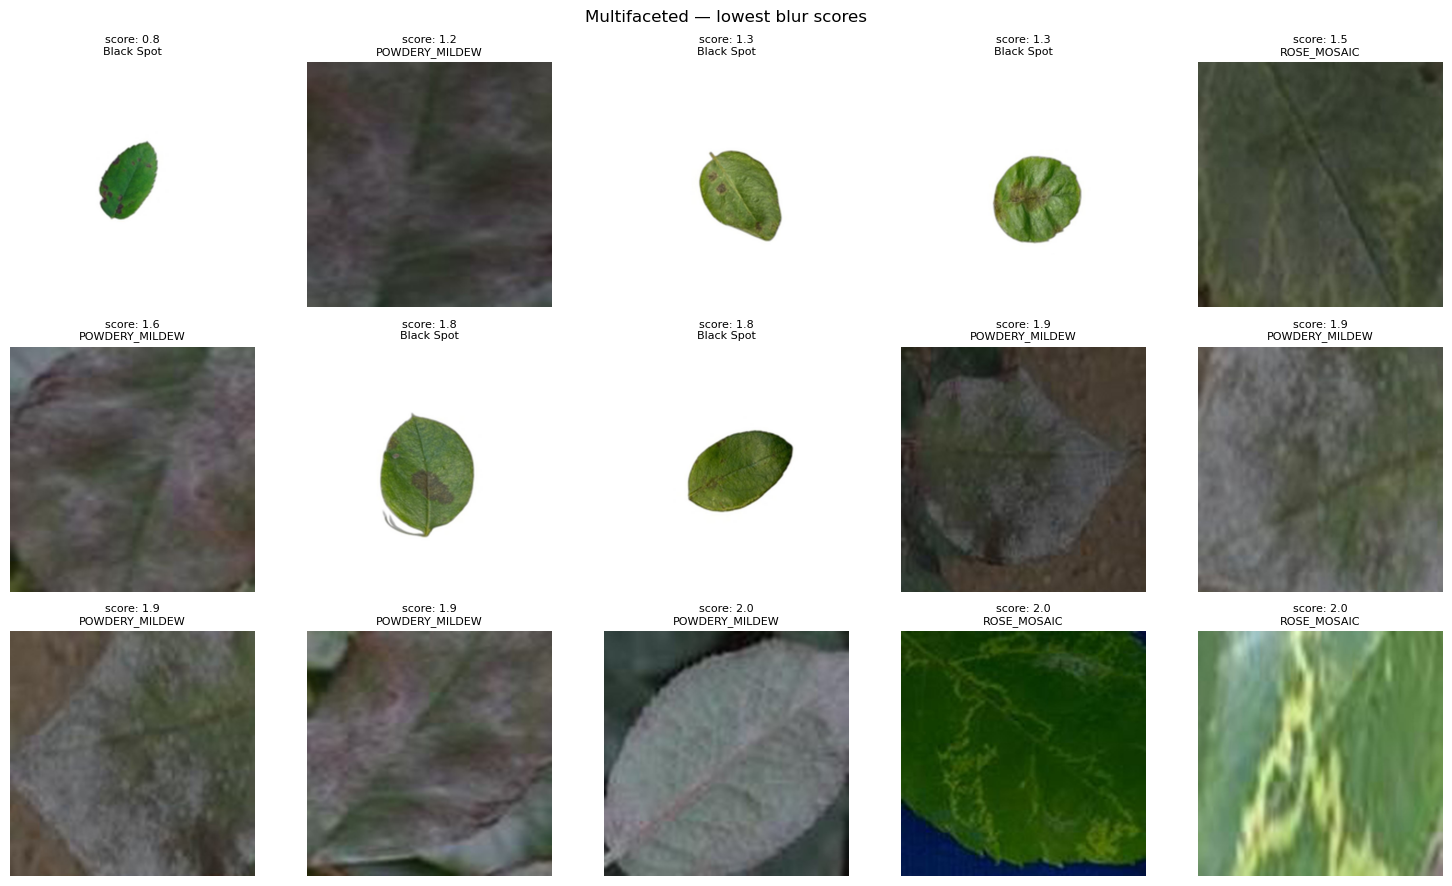

In [13]:
def show_images_by_blur(dataset_path, n_images=15, below_threshold=100.0):
    all_images = []
    for class_dir in sorted(dataset_path.rglob("*")):
        if not class_dir.is_dir():
            continue
        images = list(class_dir.glob("*.jpg")) + \
                 list(class_dir.glob("*.jpeg")) + \
                 list(class_dir.glob("*.png"))
        all_images.extend(images)

    scored = []
    for img_path in sample_images(all_images):
        score = laplacian_variance(img_path)
        if score is not None and score < below_threshold:
            scored.append((score, img_path))

    scored.sort(key=lambda x: x[0])
    to_show = scored[:n_images]

    cols = 5
    rows = (len(to_show) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    axes = axes.flatten()

    for i, (score, img_path) in enumerate(to_show):
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"score: {score:.1f}\n{img_path.parent.name}", fontsize=8)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Multifaceted — lowest blur scores", fontsize=12)
    plt.tight_layout()
    plt.show()

show_images_by_blur(DATASETS_DIR / "Multifaceted Rose Leaf Disease Dataset for AI-Driv")

## Results — Visual Inspection of Low Blur Scores (Multifaceted Dataset)

15 images with the lowest blur scores were displayed and inspected visually.
Three distinct patterns were identified:

**Pattern 1 — Small images (Black Spot, scores ~0.8–1.8):**
Images are sharp but very small (tiny leaf on white background).
Low Laplacian variance is caused by low resolution, not actual blur.
These images are usable.

**Pattern 2 — Disease texture (POWDERY_MILDEW, scores ~1.2–2.0):**
Powdery mildew creates a uniform gray/white surface with no sharp edges.
The algorithm misidentifies the disease texture as blur.
These images are usable.

**Pattern 3 — Wrong content (ROSE_MOSAIC, scores ~1.5–2.0):**
Two images appeared visually inconsistent with typical leaf photographs —
unusual color profile and texture rather than actual rose leaf photographs. These images may not be usable and indicate
potential quality issues in the ROSE_MOSAIC class.

**Conclusion:** The 78.5% below-threshold rate does not reflect actual image quality issues.
The blur metric is unreliable for datasets containing uniform-texture disease classes.
The ROSE_MOSAIC class requires further inspection before use.


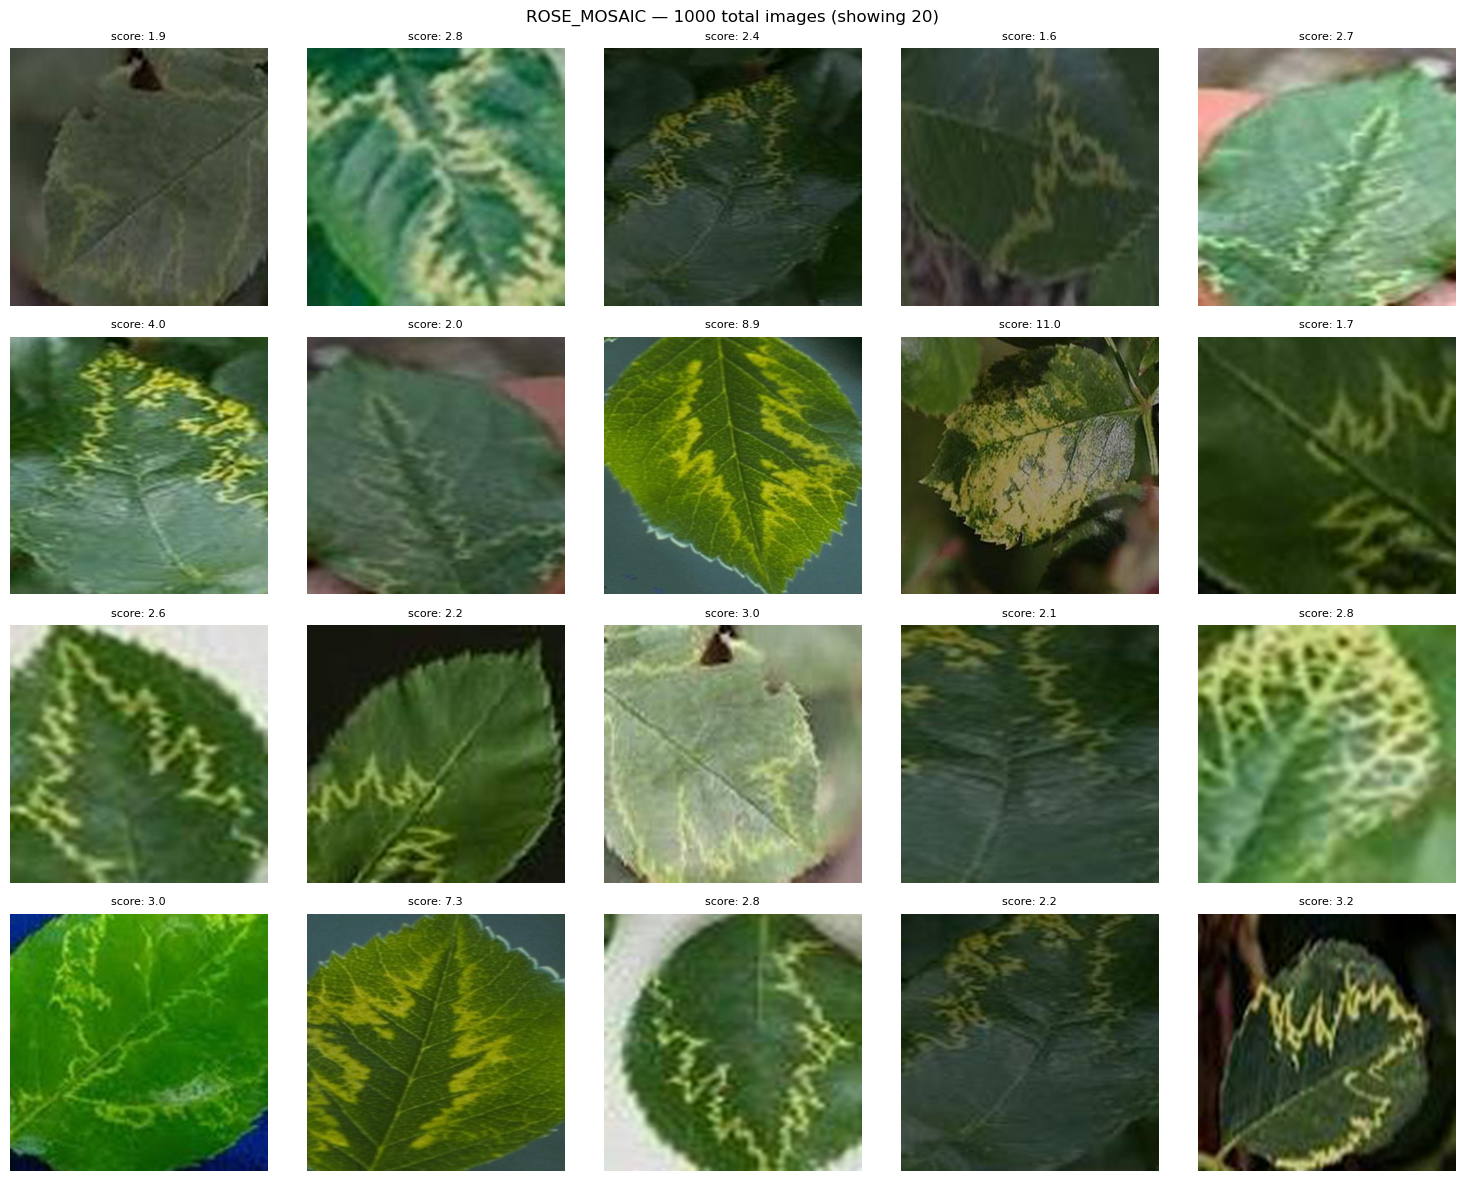

Total images in class: 1000


In [14]:
def show_class_images(class_path, n_images=20):
    images = list(class_path.glob("*.jpg")) + \
             list(class_path.glob("*.jpeg")) + \
             list(class_path.glob("*.png"))
    
    sampled = sample_images(images)[:n_images]
    
    cols = 5
    rows = (len(sampled) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    axes = axes.flatten()
    
    for i, img_path in enumerate(sampled):
        score = laplacian_variance(img_path)
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"score: {score:.1f}", fontsize=8)
        axes[i].axis("off")
    
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    
    plt.suptitle(f"ROSE_MOSAIC — {len(images)} total images (showing {len(sampled)})", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Total images in class: {len(images)}")

rose_mosaic_path = DATASETS_DIR / "Multifaceted Rose Leaf Disease Dataset for AI-Driv" / "Rose leaf dataset" / "ROSE_MOSAIC"
show_class_images(rose_mosaic_path)

## Results — ROSE_MOSAIC Class Inspection

20 images sampled from the ROSE_MOSAIC class (1,000 total).
All sampled images show consistent and recognizable Rose Mosaic Virus symptoms —
characteristic yellow-white zigzag patterns along leaf veins.

Low blur scores (1.6–11.0) are caused by the disease texture itself: mosaic patterns
create soft color gradients with low edge contrast, which the Laplacian algorithm
misidentifies as blur. The class is visually consistent and usable.

The two suspicious images observed in Cell 5 appear to be isolated outliers,
not a systemic quality issue.

Total images scored: 1000
Q1: 2.5  Median: 3.1  Q3: 4.3
IQR: 1.8  Upper bound: 6.9
Outliers (above upper bound): 121


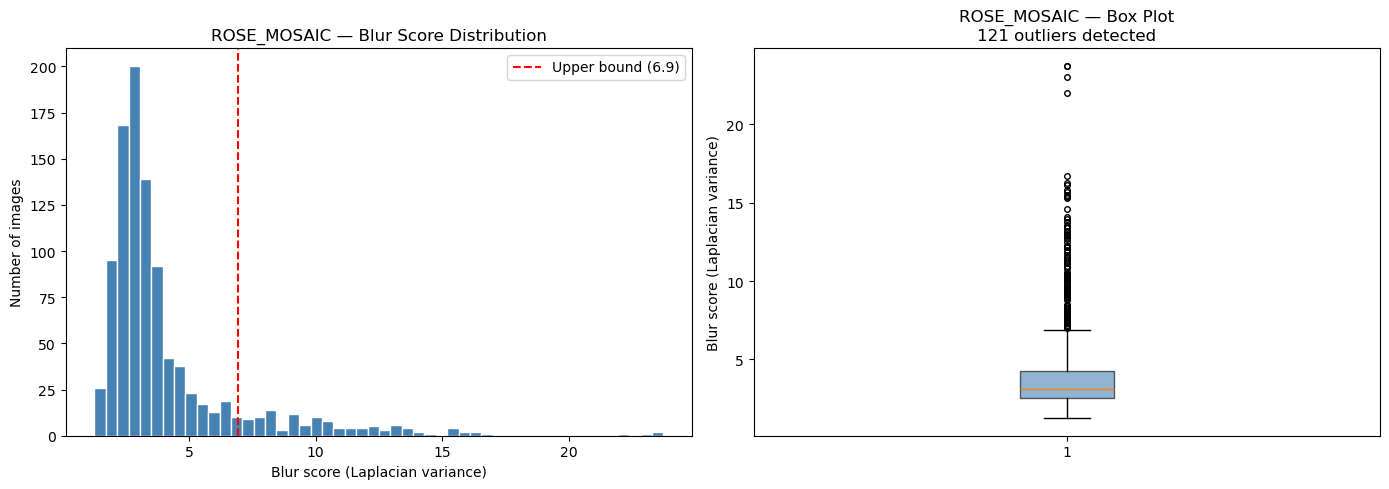

In [15]:
# Calculate blur scores for all ROSE_MOSAIC images
rose_mosaic_path = DATASETS_DIR / "Multifaceted Rose Leaf Disease Dataset for AI-Driv" / "Rose leaf dataset" / "ROSE_MOSAIC"
all_mosaic_images = list(rose_mosaic_path.glob("*.jpg")) + \
                    list(rose_mosaic_path.glob("*.jpeg")) + \
                    list(rose_mosaic_path.glob("*.png"))

mosaic_scores = []
for img_path in all_mosaic_images:
    score = laplacian_variance(img_path)
    if score is not None:
        mosaic_scores.append(score)

mosaic_scores = np.array(mosaic_scores)

# IQR-based outlier detection
Q1 = np.percentile(mosaic_scores, 25)
Q3 = np.percentile(mosaic_scores, 75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = mosaic_scores[mosaic_scores > upper_bound]

print(f"Total images scored: {len(mosaic_scores)}")
print(f"Q1: {Q1:.1f}  Median: {np.median(mosaic_scores):.1f}  Q3: {Q3:.1f}")
print(f"IQR: {IQR:.1f}  Upper bound: {upper_bound:.1f}")
print(f"Outliers (above upper bound): {len(outliers)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(mosaic_scores, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(upper_bound, color="red", linestyle="--", label=f"Upper bound ({upper_bound:.1f})")
axes[0].set_xlabel("Blur score (Laplacian variance)")
axes[0].set_ylabel("Number of images")
axes[0].set_title("ROSE_MOSAIC — Blur Score Distribution")
axes[0].legend()

# Box plot
axes[1].boxplot(mosaic_scores, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6),
                flierprops=dict(marker="o", color="red", markersize=4))
axes[1].set_ylabel("Blur score (Laplacian variance)")
axes[1].set_title(f"ROSE_MOSAIC — Box Plot\n{len(outliers)} outliers detected")

plt.tight_layout()
plt.show()

## Results — ROSE_MOSAIC Blur Score Distribution

All 1,000 images scored. Distribution is heavily concentrated between 1–7,
with upper bound (Q3 + 1.5×IQR) = 6.9 and 121 statistical outliers detected.

The 121 outliers are not bad images — they are the *sharper* images in the class
(higher Laplacian variance = more edge contrast). The IQR method flags them because
the distribution is strongly skewed toward low values.

The entire class scores below 30, compared to scores reaching 40,000+ in
rose_leaf_disease_dataset. This confirms that low blur scores in ROSE_MOSAIC
are a characteristic of the disease texture (soft color gradients, low edge contrast),
not a quality defect.

The distribution is consistent and unimodal — no evidence of a separate
population of genuinely blurry or wrong-content images. The class is usable.

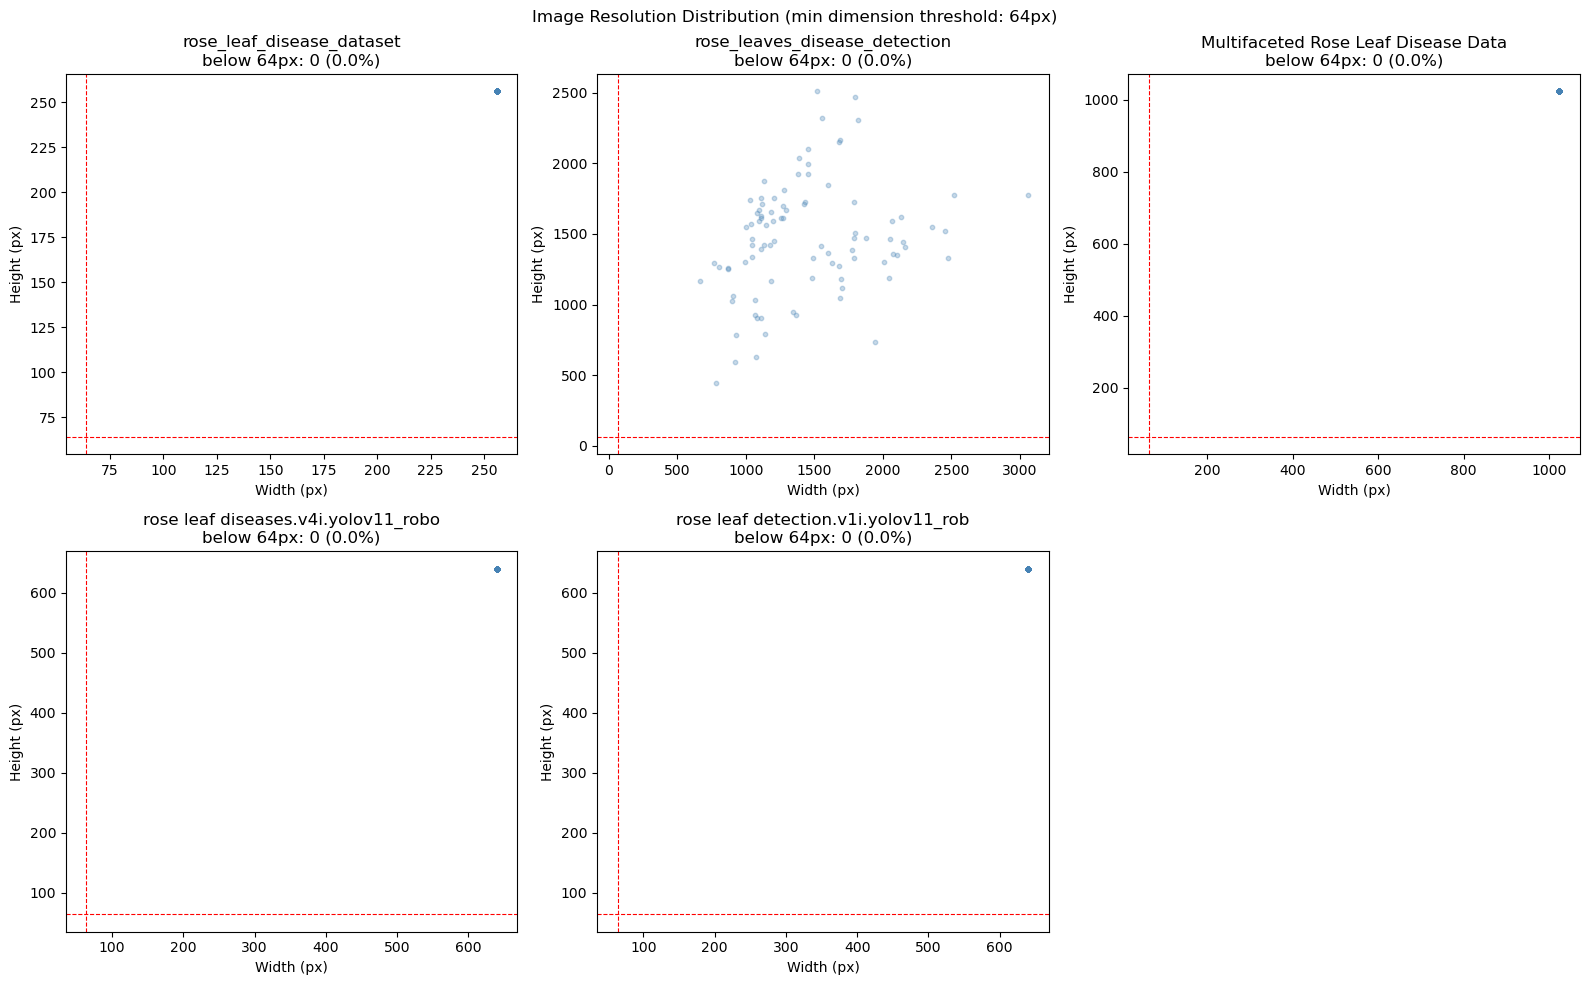


Summary:
rose_leaf_disease_dataset: 0 images below 64px (0.0%)
rose_leaves_disease_detection: 0 images below 64px (0.0%)
Multifaceted Rose Leaf Disease Dataset for AI-Driv: 0 images below 64px (0.0%)
rose leaf diseases.v4i.yolov11_roboflow: 0 images below 64px (0.0%)
rose leaf detection.v1i.yolov11_roboflow: 0 images below 64px (0.0%)

Actual dimensions (from sample):
  rose_leaf_disease_dataset: {'256×256'}
  rose_leaves_disease_detection: {'2133×1621', '1435×1728', '1518×2510', '1684×2165', '1110×1628', '1133×1874', '1820×2309', '1491×1331', '1176×1425', '1109×1396'}
  Multifaceted Rose Leaf Disease Dataset for AI-Driv: {'1024×1024'}
  rose leaf diseases.v4i.yolov11_roboflow: {'640×640'}
  rose leaf detection.v1i.yolov11_roboflow: {'640×640'}


In [19]:
MIN_SIZE = 64  # minimum acceptable dimension (width or height)

def get_image_sizes(image_list):
    widths, heights = [], []
    for img_path in image_list:
        img = cv2.imread(str(img_path))
        if img is not None:
            h, w = img.shape[:2]
            widths.append(w)
            heights.append(h)
    return np.array(widths), np.array(heights)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

all_datasets = classification_datasets + yolo_datasets
dataset_size_stats = {}

for idx, name in enumerate(all_datasets):
    path = DATASETS_DIR / name
    all_images = []

    if name in classification_datasets:
        for class_dir in sorted(path.rglob("*")):
            if class_dir.is_dir():
                imgs = list(class_dir.glob("*.jpg")) + \
                       list(class_dir.glob("*.jpeg")) + \
                       list(class_dir.glob("*.png"))
                all_images.extend(imgs)
    else:
        for split in ["train", "valid", "test"]:
            images_dir = path / split / "images"
            if images_dir.exists():
                all_images += list(images_dir.glob("*.jpg")) + \
                              list(images_dir.glob("*.jpeg")) + \
                              list(images_dir.glob("*.png"))

    sampled = sample_images(all_images)
    widths, heights = get_image_sizes(sampled)
    min_dims = np.minimum(widths, heights)
    below = np.sum(min_dims < MIN_SIZE)

    dataset_size_stats[name] = {
        "sampled": len(widths),
        "below": below,
        "below_pct": 100 * below / len(widths) if len(widths) > 0 else 0
    }

    axes[idx].scatter(widths, heights, alpha=0.3, s=10, color="steelblue")
    axes[idx].axvline(MIN_SIZE, color="red", linestyle="--", linewidth=0.8)
    axes[idx].axhline(MIN_SIZE, color="red", linestyle="--", linewidth=0.8)
    axes[idx].set_xlabel("Width (px)")
    axes[idx].set_ylabel("Height (px)")
    short_name = name[:35]
    axes[idx].set_title(f"{short_name}\nbelow {MIN_SIZE}px: {below} ({100*below/len(widths):.1f}%)")

axes[-1].axis("off")
plt.suptitle(f"Image Resolution Distribution (min dimension threshold: {MIN_SIZE}px)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nSummary:")
for name, stats in dataset_size_stats.items():
    print(f"{name[:50]}: {stats['below']} images below {MIN_SIZE}px ({stats['below_pct']:.1f}%)")

print("\nActual dimensions (from sample):")
for name in all_datasets:
    path = DATASETS_DIR / name
    all_images = []
    if name in classification_datasets:
        for class_dir in sorted(path.rglob("*")):
            if class_dir.is_dir():
                imgs = list(class_dir.glob("*.jpg")) + \
                       list(class_dir.glob("*.jpeg")) + \
                       list(class_dir.glob("*.png"))
                all_images.extend(imgs)
    else:
        for split in ["train", "valid", "test"]:
            images_dir = path / split / "images"
            if images_dir.exists():
                all_images += list(images_dir.glob("*.jpg")) + \
                              list(images_dir.glob("*.jpeg")) + \
                              list(images_dir.glob("*.png"))

    sampled = sample_images(all_images)[:10]
    sizes = set()
    for img_path in sampled:
        img = cv2.imread(str(img_path))
        if img is not None:
            h, w = img.shape[:2]
            sizes.add(f"{w}×{h}")
    print(f"  {name[:50]}: {sizes}")

## Results — Image Resolution Distribution

Threshold: 64px minimum dimension. No images below threshold in any dataset.

| Dataset | Image size | Type |
|---|---|---|
| rose_leaf_disease_dataset | 256×256 (uniform) | Pre-standardized |
| rose_leaves_disease_detection | 1109×1396 – 1820×2510 (variable) | Original photos |
| Multifaceted Rose Leaf Disease Dataset | 1024×1024 (uniform) | Pre-standardized |
| rose leaf diseases.v4i.yolov11 | 640×640 (uniform) | Roboflow export |
| rose leaf detection.v1i.yolov11 | 640×640 (uniform) | Roboflow export |

Datasets with uniform size were pre-processed by their creators.
rose_leaves_disease_detection contains original high-resolution photos with variable dimensions.
All datasets are above the minimum usable size. During training, all images will be
resized to 224×224 for MobileNet input — no resolution-based filtering required.

In [21]:
def file_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def collect_all_images(dataset_name):
    path = DATASETS_DIR / dataset_name
    images = []
    if dataset_name in classification_datasets:
        for class_dir in sorted(path.rglob("*")):
            if class_dir.is_dir():
                imgs = list(class_dir.glob("*.jpg")) + \
                       list(class_dir.glob("*.jpeg")) + \
                       list(class_dir.glob("*.png"))
                images.extend(imgs)
    else:
        for split in ["train", "valid", "test"]:
            images_dir = path / split / "images"
            if images_dir.exists():
                images += list(images_dir.glob("*.jpg")) + \
                          list(images_dir.glob("*.jpeg")) + \
                          list(images_dir.glob("*.png"))
    return images

# Step 1 — duplicates within each dataset
print("=== Within-dataset duplicates ===")
dataset_hashes = {}
for name in all_datasets:
    images = collect_all_images(name)
    hashes = {}
    for img_path in images:
        h = file_hash(img_path)
        if h not in hashes:
            hashes[h] = []
        hashes[h].append(img_path)
    duplicates = {h: paths for h, paths in hashes.items() if len(paths) > 1}
    dataset_hashes[name] = hashes
    print(f"\n{name[:50]}:")
    print(f"  Total images: {len(images)}")
    print(f"  Duplicate groups: {len(duplicates)}")
    print(f"  Duplicate images: {sum(len(p)-1 for p in duplicates.values())}")

# Step 2 — duplicates across datasets
print("\n=== Cross-dataset duplicates ===")
names = list(dataset_hashes.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        common = set(dataset_hashes[names[i]].keys()) & \
                 set(dataset_hashes[names[j]].keys())
        if common:
            print(f"{names[i][:35]} ↔ {names[j][:35]}: {len(common)} shared images")
        else:
            print(f"{names[i][:35]} ↔ {names[j][:35]}: 0 shared images")

=== Within-dataset duplicates ===

rose_leaf_disease_dataset:
  Total images: 14910
  Duplicate groups: 7050
  Duplicate images: 7860

rose_leaves_disease_detection:
  Total images: 917
  Duplicate groups: 2
  Duplicate images: 2

Multifaceted Rose Leaf Disease Dataset for AI-Driv:
  Total images: 13306
  Duplicate groups: 886
  Duplicate images: 956

rose leaf diseases.v4i.yolov11_roboflow:
  Total images: 3702
  Duplicate groups: 0
  Duplicate images: 0

rose leaf detection.v1i.yolov11_roboflow:
  Total images: 2174
  Duplicate groups: 2
  Duplicate images: 2

=== Cross-dataset duplicates ===
rose_leaf_disease_dataset ↔ rose_leaves_disease_detection: 0 shared images
rose_leaf_disease_dataset ↔ Multifaceted Rose Leaf Disease Data: 0 shared images
rose_leaf_disease_dataset ↔ rose leaf diseases.v4i.yolov11_robo: 0 shared images
rose_leaf_disease_dataset ↔ rose leaf detection.v1i.yolov11_rob: 0 shared images
rose_leaves_disease_detection ↔ Multifaceted Rose Leaf Disease Data: 0 shared im

## Results — Duplicate Detection (MD5 Hash)

### Within-dataset duplicates
| Dataset | Total | Duplicates | % |
|---|---|---|---|
| rose_leaf_disease_dataset | 14,910 | 7,860 | 52.7% |
| Multifaceted Rose Leaf Disease Dataset | 13,306 | 956 | 7.2% |
| rose_leaves_disease_detection | 917 | 2 | 0.2% |
| rose leaf diseases.v4i.yolov11 | 3,702 | 0 | 0.0% |
| rose leaf detection.v1i.yolov11 | 2,174 | 2 | 0.1% |

**rose_leaf_disease_dataset:** 52.7% duplicate rate confirms that train and validation
splits contain identical images — data leakage. The existing split must be discarded
and rebuilt after deduplication.

**Multifaceted:** 7.2% duplicates — manageable, will be removed during preprocessing.

### Cross-dataset duplicates
| Pair | Shared images |
|---|---|
| rose leaf diseases.v4i ↔ rose leaf detection.v1i | 311 |
| All other pairs | 0 |

The two YOLO datasets share 311 images — likely originating from the same source.
Deduplication required if both datasets are merged.
No overlap between any other dataset pairs.

In [22]:
import pandas as pd

summary = {
    "Dataset": [
        "rose_leaf_disease_dataset",
        "rose_leaves_disease_detection",
        "Multifaceted Rose Leaf Disease",
        "rose leaf diseases.v4i.yolov11",
        "rose leaf detection.v1i.yolov11"
    ],
    "Format": ["Classification", "Classification", "Classification", "YOLO", "YOLO"],
    "Total images": [14910, 917, 13306, 3702, 2174],
    "Classes": [3, 3, 7, 4, 3],
    "Blur (% below 100)": ["7.8%", "27.3%", "78.5%*", "40.5%", "11.1%"],
    "Duplicates": ["52.7% !!!", "0.2%", "7.2%", "0.0%", "0.1%"],
    "Resolution": ["256×256", "1109–1820px", "1024×1024", "640×640", "640×640"],
    "Split quality": ["Leakage !!!", "No split", "No split", "Broken !!!", "Good"],
    "Decision": ["Keep — deduplicate + new split",
                 "Keep — small but clean",
                 "Keep — deduplicate, skip blur filter for ROSE_MOSAIC",
                 "Keep — convert YOLO + new split",
                 "Keep — cleanest dataset"]
}

df = pd.DataFrame(summary)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.width", 120)
print(df.to_string(index=False))
print("\n* ROSE_MOSAIC blur metric unreliable — low scores caused by disease texture, not blur.")
print("** rose leaf diseases.v4i ↔ rose leaf detection.v1i share 311 images — deduplicate if merged.")

                        Dataset         Format  Total images  Classes Blur (% below 100) Duplicates  Resolution Split quality                                             Decision
      rose_leaf_disease_dataset Classification         14910        3               7.8%  52.7% !!!     256×256   Leakage !!!                       Keep — deduplicate + new split
  rose_leaves_disease_detection Classification           917        3              27.3%       0.2% 1109–1820px      No split                               Keep — small but clean
 Multifaceted Rose Leaf Disease Classification         13306        7             78.5%*       7.2%   1024×1024      No split Keep — deduplicate, skip blur filter for ROSE_MOSAIC
 rose leaf diseases.v4i.yolov11           YOLO          3702        4              40.5%       0.0%     640×640    Broken !!!                      Keep — convert YOLO + new split
rose leaf detection.v1i.yolov11           YOLO          2174        3              11.1%       0.1%     6

## Final Dataset Evaluation Summary

All 5 datasets evaluated across blur quality, resolution, duplicates, and split integrity.
Decision: all datasets are retained — issues identified here will be resolved during
preprocessing in 01_data_preparation.ipynb.

### Key findings

**Data leakage — rose_leaf_disease_dataset (52.7% duplicates):**
Train and validation splits contain identical images. The existing split is invalid.
Action: deduplicate all images, then rebuild train/val/test split from scratch.

**Broken splits — rose leaf diseases.v4i.yolov11:**
Valid and test splits are missing entire classes (Black Spot absent from both).
Action: discard existing splits, merge all images, rebuild split after YOLO conversion.

**Moderate duplicates — Multifaceted (7.2%):**
Action: remove duplicates during preprocessing. Do not apply standard blur
threshold (100) to ROSE_MOSAIC class — low scores reflect disease texture, not blur.

**Cross-dataset overlap — v4i ↔ v1i YOLO (311 shared images):**
Action: deduplicate if both datasets are merged into the same training pool.

### Preprocessing actions required before training
1. Deduplicate: rose_leaf_disease_dataset, Multifaceted, YOLO pair if merged
2. Rebuild splits: rose_leaf_disease_dataset, rose leaf diseases.v4i.yolov11
3. Convert YOLO to classification format: both YOLO datasets
4. Resize all images to 224×224 for MobileNet input
5. Skip blur filtering for ROSE_MOSAIC class
